# 场图 (fieldplot) 能力演示

对应 05_fieldplot.ipynb: 腔场 Ez/Er/Bphi 二维图 + 轴上场; 3D 场图
四种视图 (矢量剖面 / 2D 等值线 / 标量剖面 / 3D 等值线); 螺线管 Bz
二维图 + 轴上曲线; 通用一维场剖面与弯曲阴极轮廓; 阴极表面场; 激光
3D 图轴上剖面; 等离子体密度剖面。离轴场按手册第 8 章由轴上场展开。

In [4]:
%run ../notebooks/_bootstrap.py

astra-notebook 后端已加载 (v0.1.0)
项目根目录: /Users/yuxinwu/my_projects/astra_notebook
模拟工作目录: /Users/yuxinwu/my_projects/astra_notebook/data/workspace
ASTRA    : /Users/yuxinwu/programs/ASTRA/astra
Generator: /Users/yuxinwu/programs/ASTRA/generator


腔场: 343 个 z 点, 峰值 Ez = 14610.53 (任意单位, 按 MaxE 缩放)


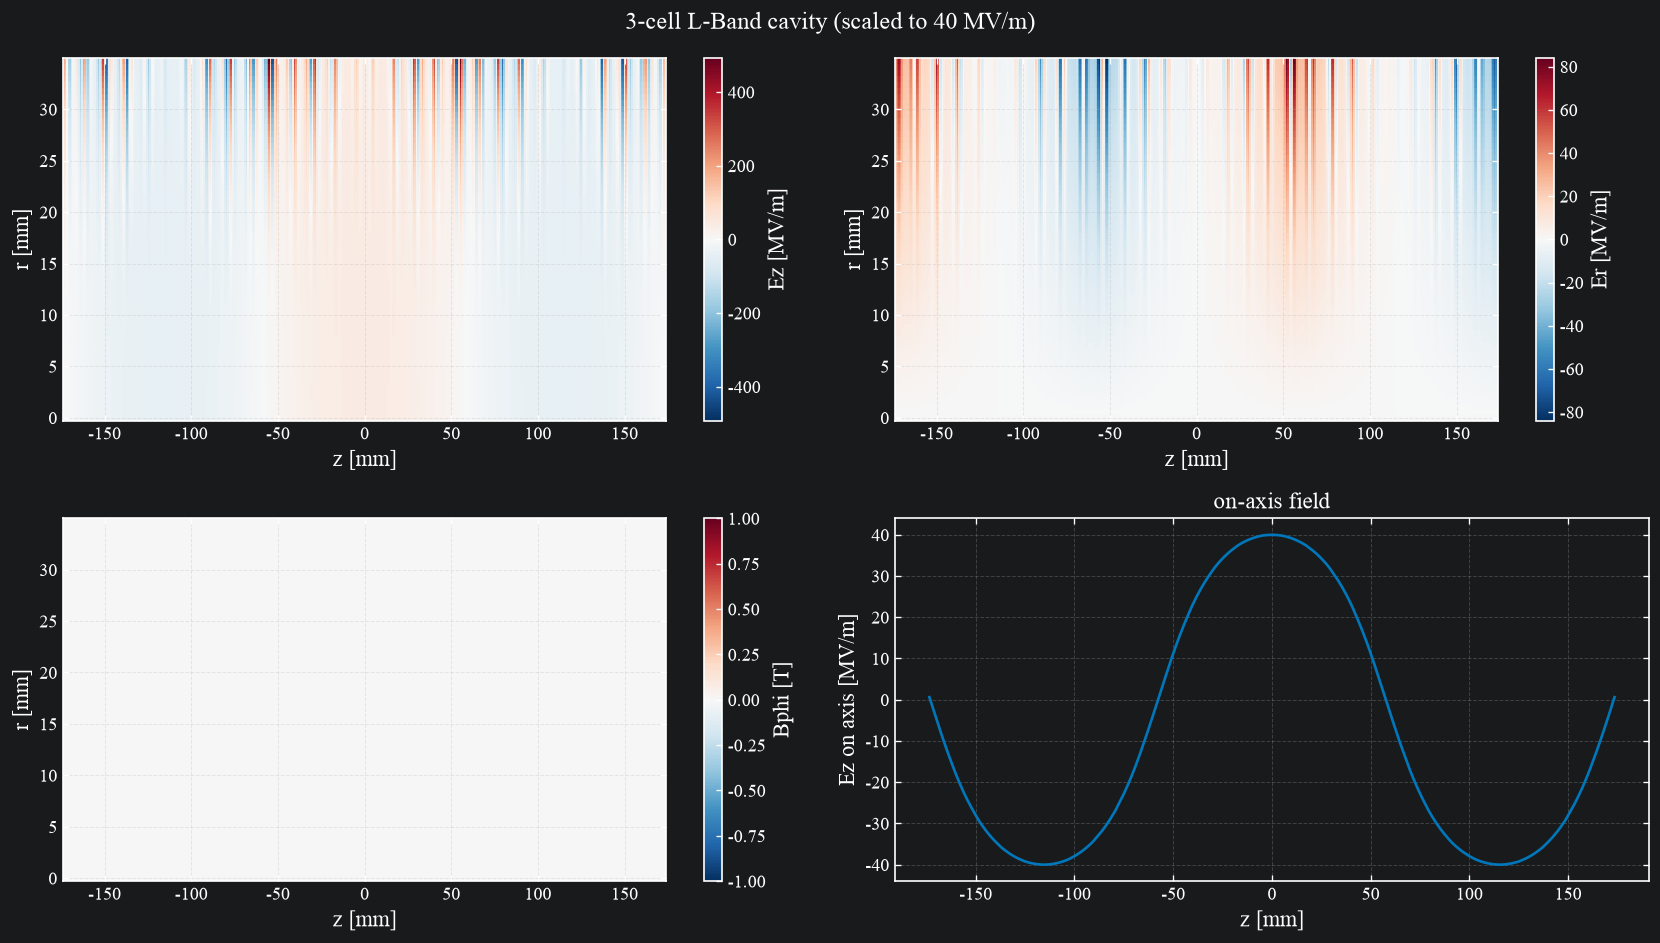

In [ ]:
from astra_tools.io.field_map import read_cavity_field
from astra_tools.plot.field_plots import plot_cavity_field

cav = read_cavity_field(
    PROJECT_ROOT / "examples/Manual_Example/3_cell_L-Band.dat")
print("腔场: %d 个 z 点, 峰值 Ez = %.2f (任意单位, 按 MaxE 缩放)"
      % (len(cav.z), cav.peak_field_arb))
plot_cavity_field(cav, maxE_MVpm=40,
                  title="3-cell L-Band cavity (scaled to 40 MV/m)");

## 3D 场图 (fieldplot 菜单 2)

统一入口的矢量剖面 / 等值线 / 标量剖面 / 3D 等值线四种视图 (Cavity_Example
的 3D_test 电场 + 90deg_bend 的 3D 二极磁场: 底色 = |F|, 箭头 = 面内分量,
plane 选显示平面, xz/yz 中 z 在横轴)。

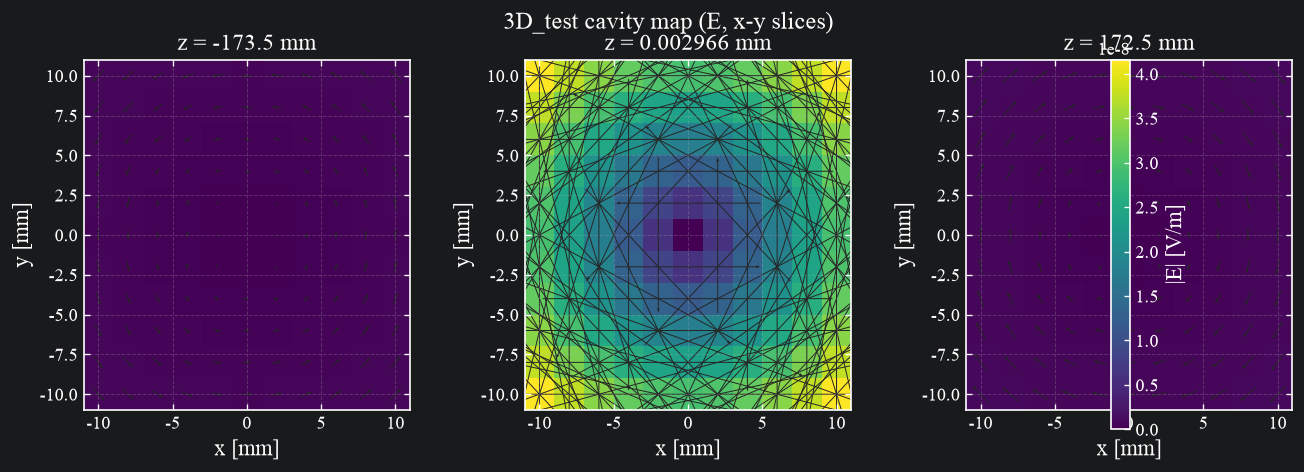

In [ ]:
from astra_tools.plot.field_plots import plot_3d_field_map
m3d = PROJECT_ROOT / "examples/Cavity_Example/3D_test"
if (PROJECT_ROOT / "examples/Cavity_Example/3D_test.ex").exists():
    plot_3d_field_map(m3d, view="vector_slices", plane="xy", n_slices=3,
                      title="3D_test cavity map (E, x-y slices)");
else:
    print("3D 场图文件不存在")

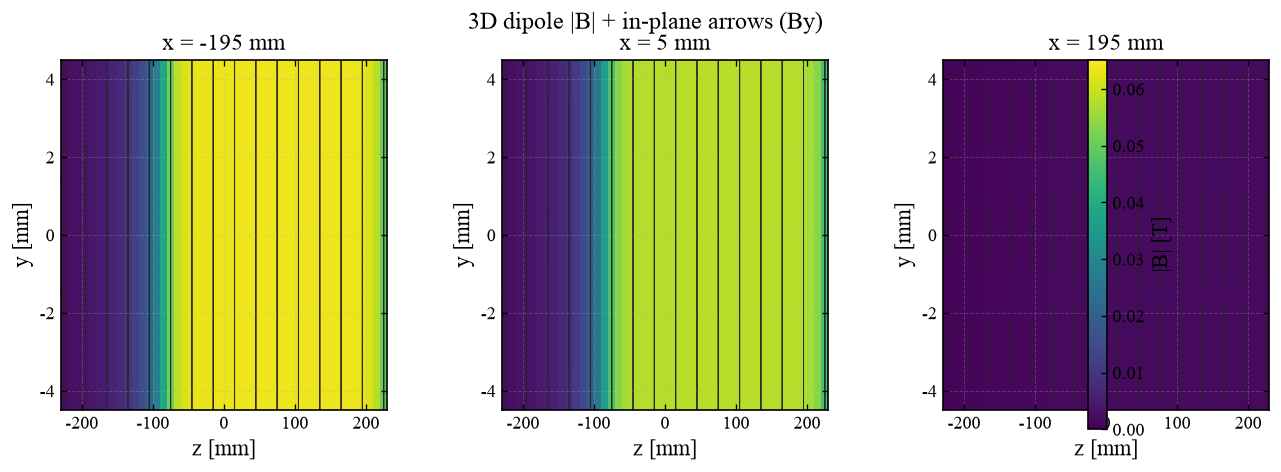

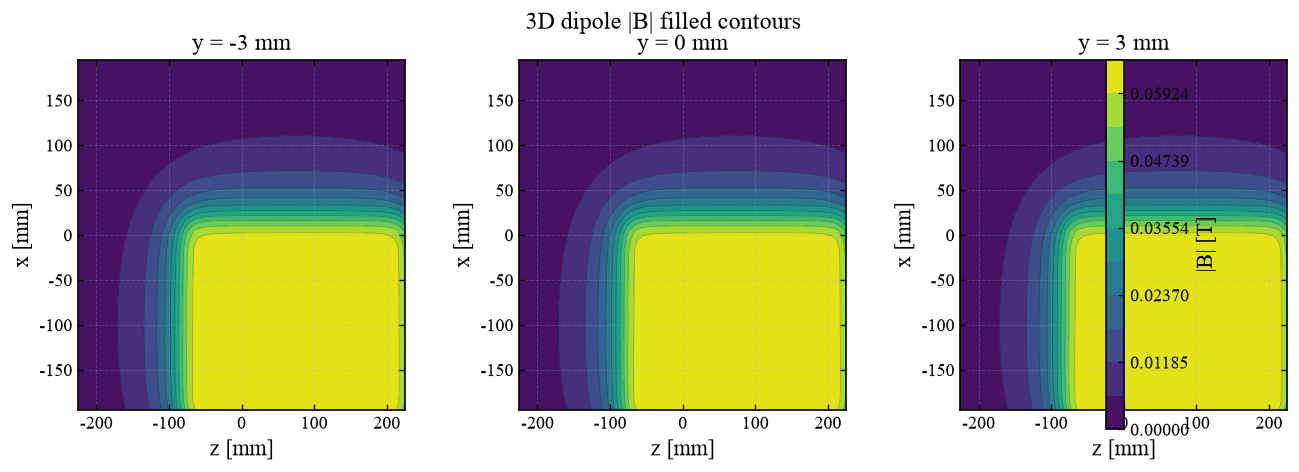

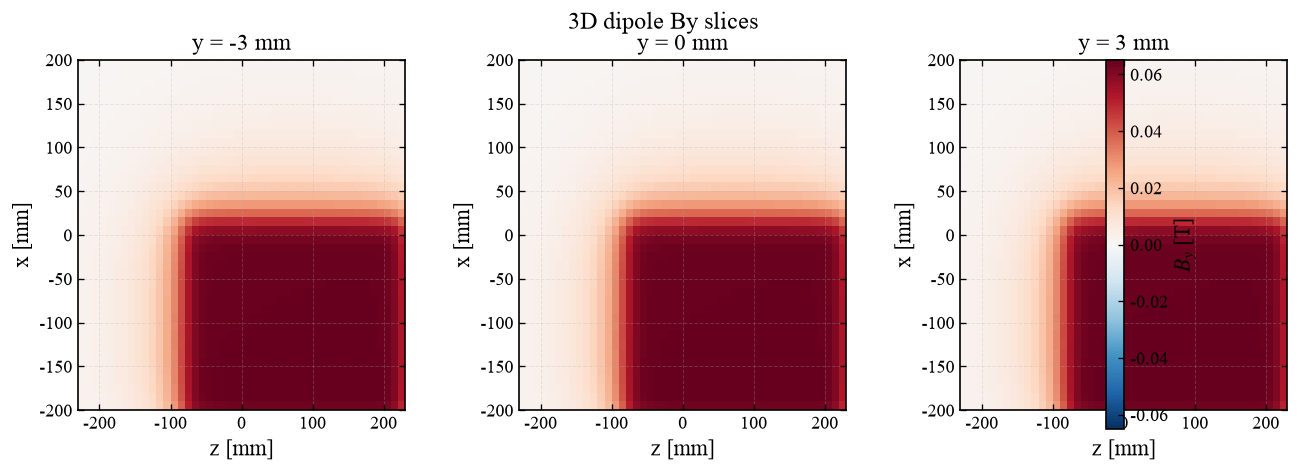

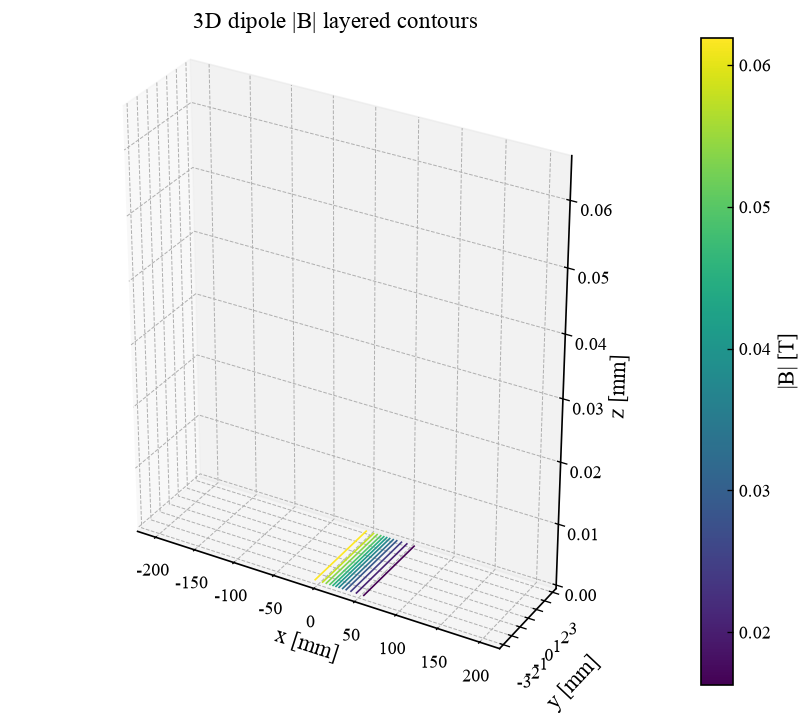

In [8]:
from astra_tools.plot.field_plots import plot_3d_field_map
dip = PROJECT_ROOT / "examples/90deg_bend_Example/3D_Dipole.bx"
# 该场图只有 By 非零 (bx=bz=0), 故矢量剖面用 plane="yz" (面内 by/bz)
# 才能看到箭头; plane="xz" 面内分量全零会只剩底色 (物理事实)。
plot_3d_field_map(dip, view="vector_slices", plane="yz", n_slices=3,
                  title="3D dipole |B| + in-plane arrows (By)")
plot_3d_field_map(dip, view="contour", plane="xz", n_slices=3,
                  title="3D dipole |B| filled contours")
plot_3d_field_map(dip, view="scalar_slices", plane="xz",
                  component="y", n_slices=3,
                  title="3D dipole By slices")
plot_3d_field_map(dip, view="contour3d", n_planes=5,
                  title="3D dipole |B| layered contours");

螺线管: 1200 个 z 点, 峰值 Bz = 0.350 T (MaxB=0.35)


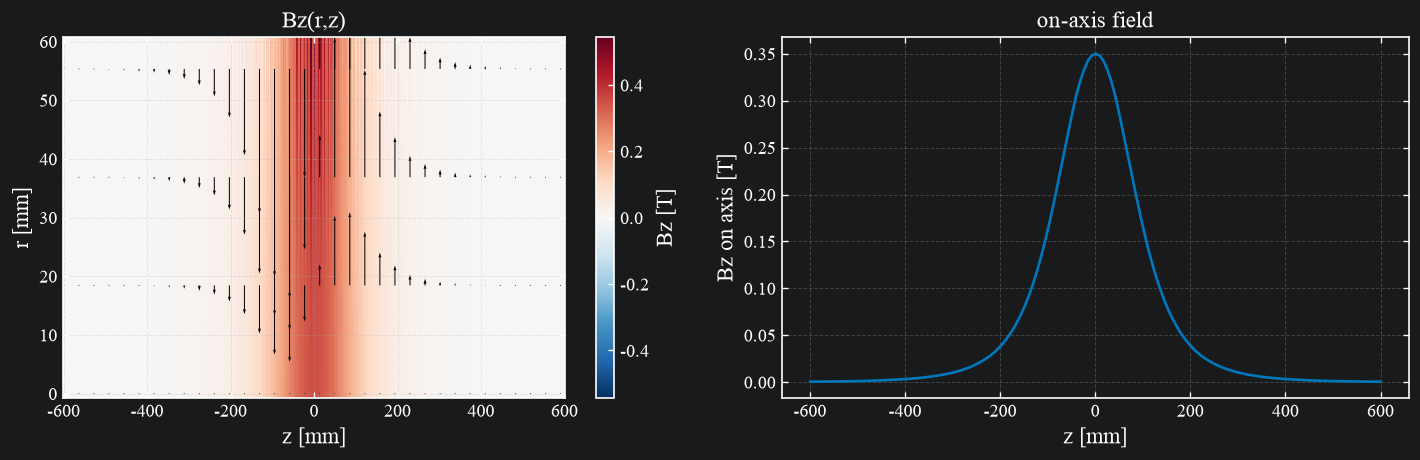

In [ ]:
from astra_tools.io.field_map import read_solenoid_field
from astra_tools.plot.field_plots import plot_solenoid_field
sol = read_solenoid_field(
    PROJECT_ROOT / "examples/Manual_Example/Solenoid.dat").scaled(0.35)
print("螺线管: %d 个 z 点, 峰值 Bz = %.3f T (MaxB=0.35)"
      % (len(sol.z), sol.bz0.max()))
plot_solenoid_field(sol);

## 通用一维场剖面与弯曲阴极 (fieldplot 菜单 1)

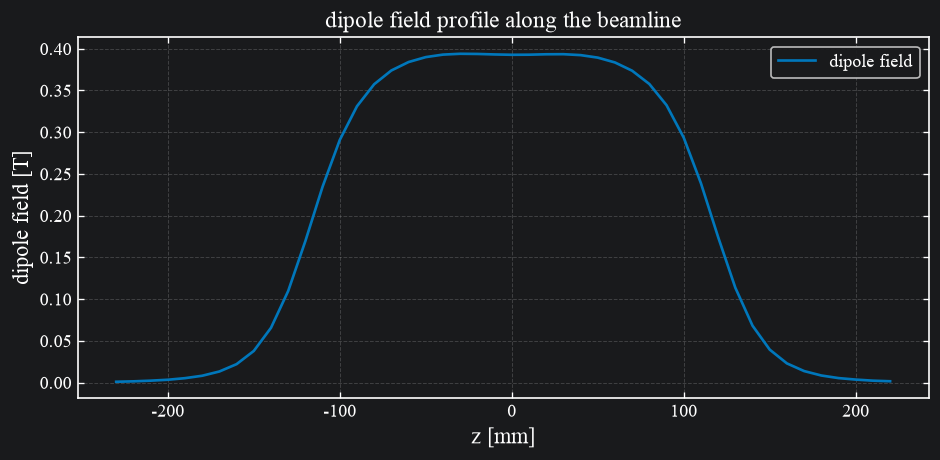

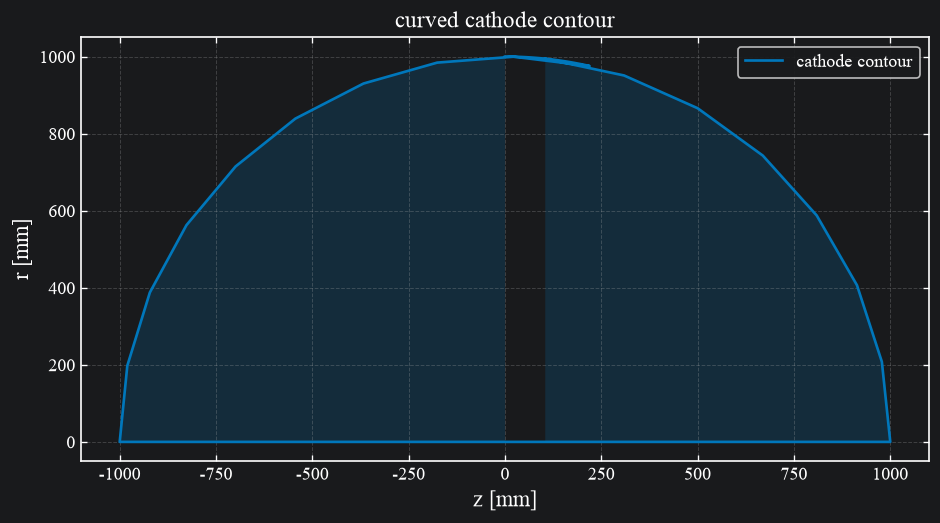

In [ ]:
from astra_tools.plot.advanced_plots import (
    plot_field_profile, plot_curved_cathode_contour)
plot_field_profile(
    PROJECT_ROOT / "examples/WHPS_LINAC/115-143/bfld_scand.dat",
    label="dipole field", unit="T",
    title="dipole field profile along the beamline")
plot_curved_cathode_contour(
    PROJECT_ROOT / "examples/Curved_Cathode_Example/Contour.dat",
    title="curved cathode contour");

## 阴极表面场 (CathodeS=T 时 ASTRA 输出)

加速场 + 空间电荷场 + 发射电荷 vs 时间; 仓库没有 Cathode 产物,
用合成教学数据演示 (真实文件换路径即可)。

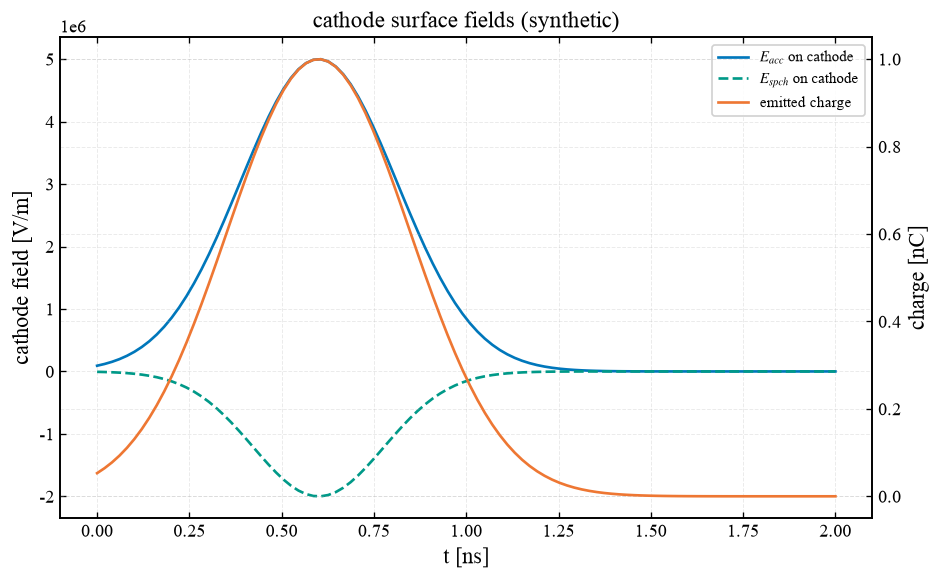

In [9]:
import numpy as np
from astra_tools.plot.advanced_plots import plot_cathode_emission
# 注意: Cathode 文件 charge 列单位为 nC (手册 Table 4), 合成数据按 nC 给。
t = np.linspace(0, 2e-9, 100)
cathode = dict(
    t=t,
    E_acc=5e6 * np.exp(-((t - 0.6e-9) / 0.3e-9) ** 2),
    E_spch=-2e6 * np.exp(-((t - 0.6e-9) / 0.25e-9) ** 2),
    q=1.0 * np.exp(-((t - 0.6e-9) / 0.35e-9) ** 2))
plot_cathode_emission(cathode,
                      title="cathode surface fields (synthetic)");

## 激光 3D 图的轴上剖面 (fieldplot 8 章, vs z 与 vs t)

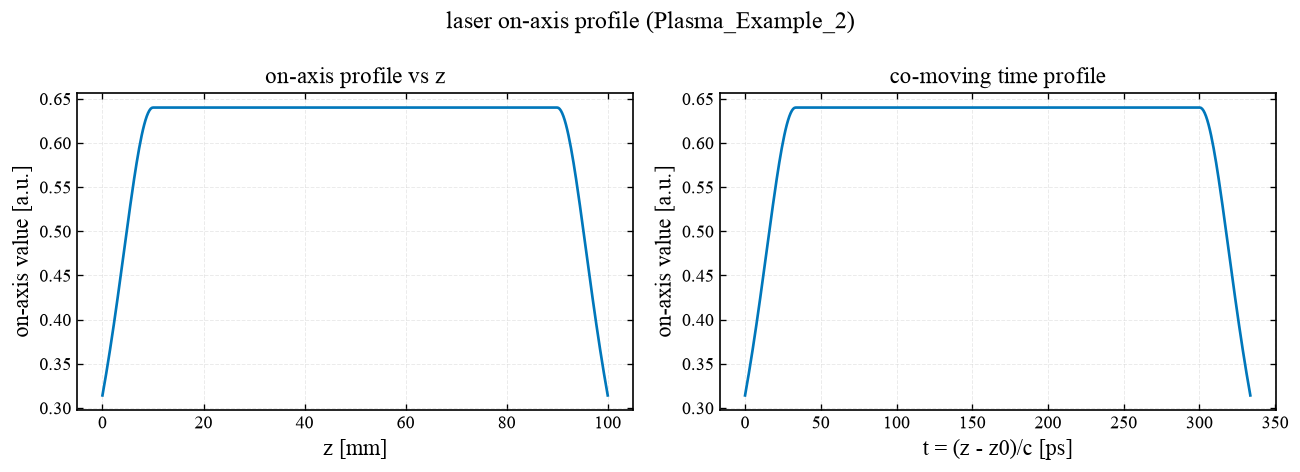

In [6]:
# 真实 laser.dat 是 65 MB gitignore 物料 (Plasma_Example_2),
# 存在时直接用; 缺失时合成小图走同一条读图/画图路径。
import numpy as np
from astra_tools.plot.advanced_plots import plot_laser_on_axis

laser_real = PROJECT_ROOT / "examples/Plasma_Example_2/laser.dat"
if laser_real.exists():
    plot_laser_on_axis(laser_real, unit="a.u.",
                       title="laser on-axis profile (Plasma_Example_2)")
else:
    laser = SIM_DIR / "demo_laser.dat"
    nx, ny, nz = 21, 21, 200
    x = np.linspace(-1e-3, 1e-3, nx)
    y = np.linspace(-1e-3, 1e-3, ny)
    z = np.linspace(0, 2e-3, nz)
    XX, YY, ZZ = np.meshgrid(x, y, z, indexing="ij")
    f = np.exp(-(XX ** 2 + YY ** 2) / (0.3e-3) ** 2) * np.exp(
        -((ZZ - 1e-3) / 0.4e-3) ** 2)
    with open(laser, "w") as fh:
        for g in (x, y, z):
            fh.write("%d " % len(g)
                     + " ".join("%.8g" % v for v in g) + chr(10))
        np.savetxt(fh, f.ravel(order="F"))
    print("真实 laser.dat 缺失, 已生成合成教学图: %s" % laser)
    plot_laser_on_axis(laser, unit="a.u.",
                       title="laser on-axis profile (synthetic)")

## 等离子体密度剖面 (File_Efield='Plasma...' 两列表, 手册 6.7)

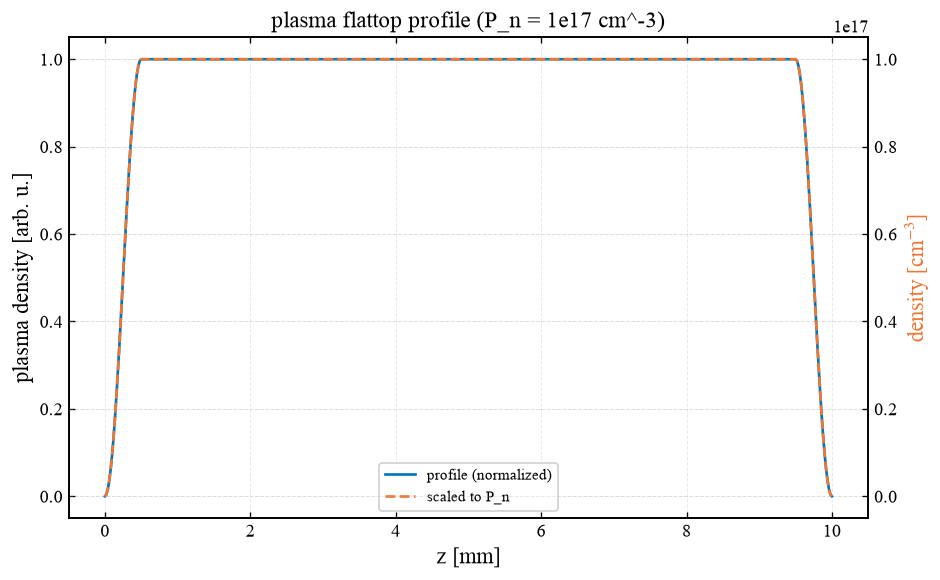

In [7]:
from astra_tools.plot.advanced_plots import plot_plasma_profile
pfile = PROJECT_ROOT / "examples/Plasma_Example_1/PLASMA_flattop.txt"
plot_plasma_profile(pfile, peak_density_cm3=1e17,
                    title="plasma flattop profile (P_n = 1e17 cm^-3)");

要点: 所有离轴场由轴上场经手册第 8 章展开 (CavityField.field_at /
SolenoidField.field_at); 3D 场图单位按文件名约定自动推导 (ex/ey/ez ->
V/m, bx/by/bz -> T)。

## TE 模场 + 场展开半径 R3rd (手册 6.9/8 章)

TE 模场文件以 'TE_' 开头, 存轴上纵向磁场 Bz; 离轴 Bz/Br/Eφ 按手册
第 8 章 TE 展开 (含 ω²/c² 项)。R3rd 为场展开有效半径 (对数值噪声
敏感, 图内已做轻度平滑 + 分位裁剪)。


In [ ]:
# TE 模场 (合成, 真实 TE_ 文件换路径) + 场展开半径 R3rd (TM/TE/螺线管)
import numpy as np
from astra_tools.io.field_map import TEField
from astra_tools.plot.field_plots import plot_te_field, plot_field_expansion_radius

_z = np.linspace(0, 0.3, 201)
te = TEField(z=_z, bz0=np.exp(-((_z - 0.15) / 0.05) ** 2))
OMEGA_RF = 2 * np.pi * 1.3e9          # L-band RF 角频率
plot_te_field(te, omega=OMEGA_RF, max_field=0.1,
              title="TE mode fields (synthetic)")
plot_field_expansion_radius(cav, omega=OMEGA_RF,
                            title="R3rd for TM cavity (3_cell_L-Band)")
plot_field_expansion_radius(te, omega=OMEGA_RF,
                            title="R3rd for TE mode (demo)")
plot_field_expansion_radius(sol, title="R3rd for solenoid (static)")


## 螺线管/四极 next page + 激光包络 + 等离子体 vs z/zeta + 电荷环

螺线管 next page (单独 Bz/Br + R3rd)、四极 next page (Bz + 综合图)、
激光 rms 束包络 + 焦点位置、等离子体场 vs z / vs zeta (线性尾场解析
模型)、弯曲阴极电荷环位置。


In [ ]:
# 螺线管/四极 next page + 激光 rms 包络·焦点 + 等离子体 vs z/zeta + 电荷环
from astra_tools.plot.field_plots import plot_solenoid_components
from astra_tools.plot.advanced_plots import (
    plot_quadrupole_field, plot_laser_envelope, plot_plasma_fields,
    plot_curved_cathode_contour)
from pathlib import Path

plot_solenoid_components(sol, title="solenoid next page: Bz/Br alone + R3rd")

# 四极: 两列 (z,G) 用理想 Gy=-Gx; 四列含 Bz 时可显示纵向场
qz = np.linspace(0, 1.0, 80)
qd = Path("_quad_demo.dat")
np.savetxt(qd, np.column_stack([qz, 5 * np.ones(80), -5 * np.ones(80)]))
plot_quadrupole_field(str(qd), title="quadrupole: gradients + next page")
qd.unlink(missing_ok=True)

# 激光 rms 束包络 + 焦点位置 (5.7.3)
laser_src = laser_real if laser_real.exists() else laser
plot_laser_envelope(laser_src, title="laser rms beam envelope & focus")

# 等离子体场 vs z / vs zeta (线性尾场解析模型, 手册附录)
plot_plasma_fields(pfile, peak_density_cm3=1e17, vs="z",
                   title="plasma fields vs z")
plot_plasma_fields(pfile, peak_density_cm3=1e17, vs="zeta",
                   title="plasma fields vs zeta")

# 弯曲阴极 + 电荷环位置 (手册 4.4.5)
cc = PROJECT_ROOT / "examples/Curved_Cathode_Example/Contour.dat"
if cc.exists():
    plot_curved_cathode_contour(cc, show_rings=True,
                                title="curved cathode + charge rings")
else:
    print("无 Contour.dat")
